Spike matrix shape: (994, 1000)


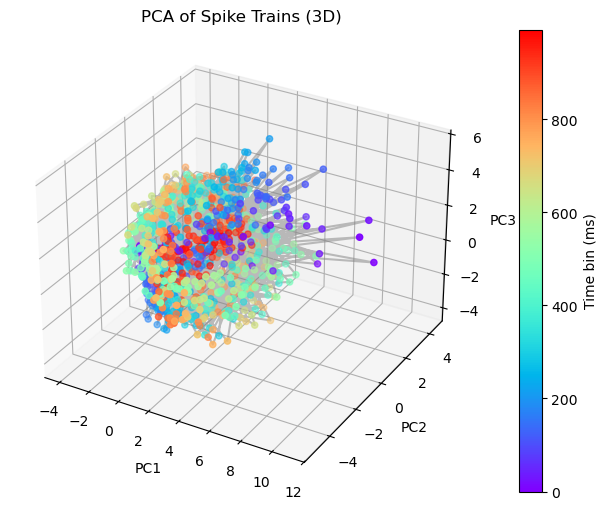

In [9]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ========= Step 1. 读取 CSV =========
# 包含两列：senders, times
df = pd.read_csv("/Users/haotianli/Code/ZhouLab/data_folder/brunel_1000neuron_1000ms.csv")

# ========= Step 2. 构建 spike matrix =========
# 取时间范围（ms，取整）
time_min = int(np.floor(df['times'].min()))
time_max = int(np.ceil(df['times'].max()))

# 获取神经元 index
neurons = sorted(df['senders'].unique())
neuron_index = {nid: i for i, nid in enumerate(neurons)}

# 初始化矩阵 [时间 × 神经元]
spike_matrix = np.zeros((time_max - time_min + 1, len(neurons)))

# 填充 spike
for _, row in df.iterrows():
    t = int(round(row['times'])) - time_min
    n = neuron_index[row['senders']]
    spike_matrix[t, n] += 1

print("Spike matrix shape:", spike_matrix.shape)

# ========= Step 1. PCA 改成 3 个主成分 =========
pca = PCA(n_components=3)
spike_pca = pca.fit_transform(spike_matrix)

# ========= Step 2. 3D 可视化 =========
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    spike_pca[:, 0], spike_pca[:, 1], spike_pca[:, 2],
    c=range(spike_pca.shape[0]),
    cmap="rainbow",  # 彩虹色
    s=20
)

# 可选：轨迹线
ax.plot(spike_pca[:, 0], spike_pca[:, 1], spike_pca[:, 2], color="gray", alpha=0.5)

ax.set_title("PCA of Spike Trains (3D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
fig.colorbar(sc, label="Time bin (ms)")

plt.show()


In [10]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# ========= Step 1. 读取 CSV =========
df = pd.read_csv("/Users/haotianli/Code/ZhouLab/data_folder/brunel_1000neuron_1000ms.csv")

# ========= Step 2. 构建 spike matrix =========
time_min = int(np.floor(df['times'].min()))
time_max = int(np.ceil(df['times'].max()))

neurons = sorted(df['senders'].unique())
neuron_index = {nid: i for i, nid in enumerate(neurons)}

spike_matrix = np.zeros((time_max - time_min + 1, len(neurons)))
for _, row in df.iterrows():
    t = int(round(row['times'])) - time_min
    n = neuron_index[row['senders']]
    spike_matrix[t, n] += 1

# ========= Step 3. PCA =========
pca = PCA(n_components=3)
spike_pca = pca.fit_transform(spike_matrix)

# ========= Step 4. Plotly 交互式 3D Trace =========
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=spike_pca[:,0],
    y=spike_pca[:,1],
    z=spike_pca[:,2],
    mode='lines+markers',
    marker=dict(
        size=4,
        color=list(range(spike_pca.shape[0])),
        colorscale='Rainbow',
        colorbar=dict(title="Time bin (ms)")
    ),
    line=dict(color='gray', width=2),
    text=[f"Time bin: {t}" for t in range(spike_pca.shape[0])],
    hoverinfo="text"
))

fig.update_layout(
    title="Interactive 3D PCA of Spike Trains",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    )
)

fig.show()


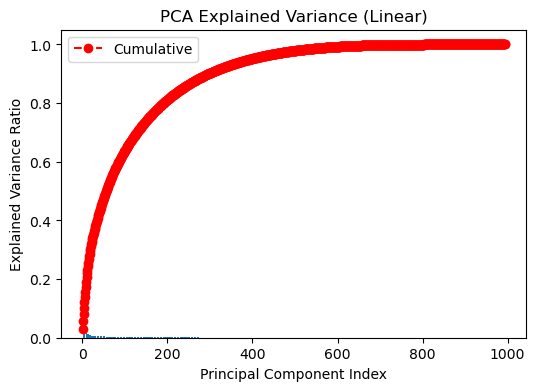

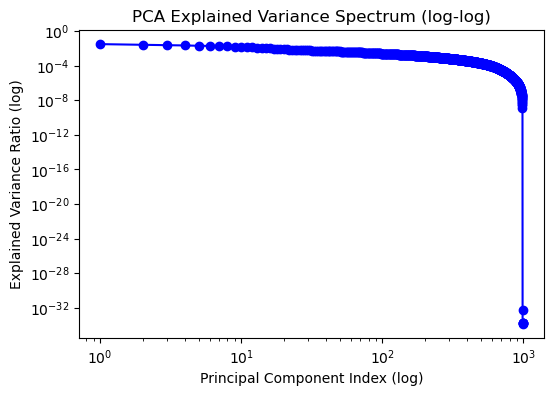

In [12]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ========= Step 1. 读取 CSV =========
df = pd.read_csv("/Users/haotianli/Code/ZhouLab/data_folder/brunel_1000neuron_1000ms.csv")

# ========= Step 2. 构建 spike matrix =========
time_min = int(np.floor(df['times'].min()))
time_max = int(np.ceil(df['times'].max()))

neurons = sorted(df['senders'].unique())
neuron_index = {nid: i for i, nid in enumerate(neurons)}

spike_matrix = np.zeros((time_max - time_min + 1, len(neurons)))
for _, row in df.iterrows():
    t = int(round(row['times'])) - time_min
    n = neuron_index[row['senders']]
    spike_matrix[t, n] += 1

# ========= Step 3. PCA =========
pca = PCA()
pca.fit(spike_matrix)
explained_var = pca.explained_variance_ratio_

# ========= Step 4. 线性坐标图 =========
plt.figure(figsize=(6,4))
plt.bar(range(1, len(explained_var)+1), explained_var)
plt.plot(range(1, len(explained_var)+1), np.cumsum(explained_var), 'r--o', label="Cumulative")
plt.xlabel("Principal Component Index")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance (Linear)")
plt.legend()
plt.show()

# ========= Step 5. log-log plot =========
plt.figure(figsize=(6,4))
plt.loglog(range(1, len(explained_var)+1), explained_var, 'bo-')
plt.xlabel("Principal Component Index (log)")
plt.ylabel("Explained Variance Ratio (log)")
plt.title("PCA Explained Variance Spectrum (log-log)")
plt.show()


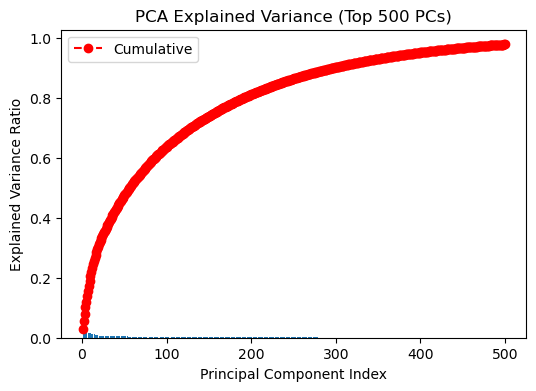

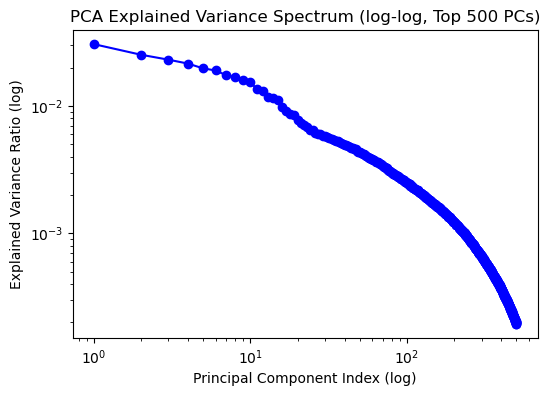

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# ========= 假设 spike_matrix 已经构建好 =========
pca = PCA()
pca.fit(spike_matrix)
explained_var = pca.explained_variance_ratio_

# ========= 截断到前100个 =========
k = 500
explained_var_trunc = explained_var[:k]

# 线性坐标
plt.figure(figsize=(6,4))
plt.bar(range(1, k+1), explained_var_trunc)
plt.plot(range(1, k+1), np.cumsum(explained_var_trunc), 'r--o', label="Cumulative")
plt.xlabel("Principal Component Index")
plt.ylabel("Explained Variance Ratio")
plt.title(f"PCA Explained Variance (Top {k} PCs)")
plt.legend()
plt.show()

# log-log 坐标
plt.figure(figsize=(6,4))
plt.loglog(range(1, k+1), explained_var_trunc, 'bo-')
plt.xlabel("Principal Component Index (log)")
plt.ylabel("Explained Variance Ratio (log)")
plt.title(f"PCA Explained Variance Spectrum (log-log, Top {k} PCs)")
plt.show()


100%|██████████| 200/200 [00:05<00:00, 34.08it/s]


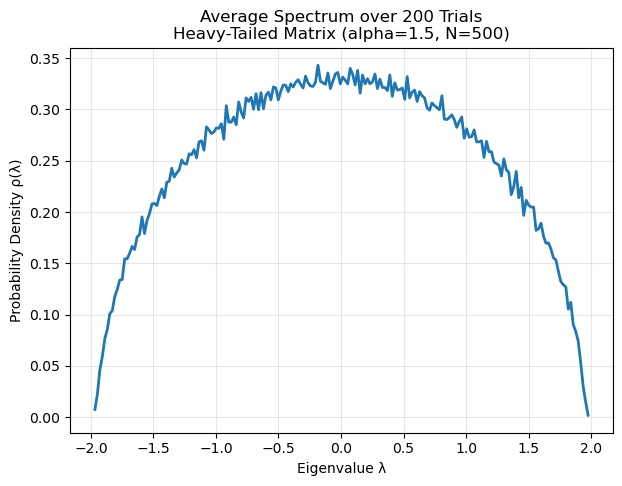

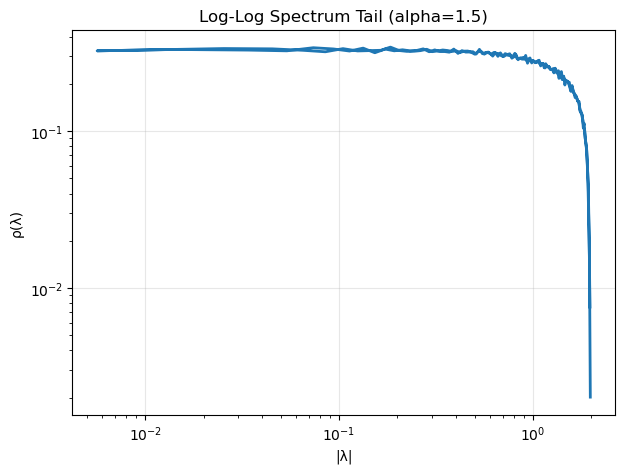

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# -------------------------------
# 参数设置
# -------------------------------
N = 500            # 矩阵维度
alpha = 1.5        # heavy-tail指数 (Pareto or Lévy tail)
n_trials = 200     # 实验次数
n_bins = 200       # 直方图分箱数
truncate = 20      # 截断阈值防止数值爆炸

# -------------------------------
# 生成 heavy-tail 矩阵的函数
# -------------------------------
def heavy_tailed_matrix(N, alpha=1.5, truncate=None):
    # 1. 生成服从Pareto分布的随机数
    x = np.random.pareto(alpha, size=(N, N)) + 1  # +1 shift避免极小值
    signs = np.random.choice([-1, 1], size=(N, N))
    M = signs * x

    # 2. 截断极端值防止数值发散
    if truncate is not None:
        M = np.clip(M, -truncate, truncate)

    # 3. 对称化
    M = (M + M.T) / 2.0

    # 4. normalization: Wigner heavy-tail scaling
    M /= N**(1/alpha)

    return M

# -------------------------------
# 主仿真
# -------------------------------
all_eigs = []

for _ in tqdm(range(n_trials)):
    C = heavy_tailed_matrix(N, alpha=alpha, truncate=truncate)
    eigvals = np.linalg.eigvalsh(C)  # 对称矩阵专用
    all_eigs.extend(eigvals)

all_eigs = np.array(all_eigs)

# -------------------------------
# 绘制平均谱分布
# -------------------------------
hist, bins = np.histogram(all_eigs, bins=n_bins, density=True)
centers = 0.5 * (bins[1:] + bins[:-1])

plt.figure(figsize=(7, 5))
plt.plot(centers, hist, lw=2)
plt.title(f"Average Spectrum over {n_trials} Trials\nHeavy-Tailed Matrix (alpha={alpha}, N={N})")
plt.xlabel("Eigenvalue λ")
plt.ylabel("Probability Density ρ(λ)")
plt.grid(alpha=0.3)

# 对数坐标看尾部幂律
plt.figure(figsize=(7, 5))
plt.loglog(np.abs(centers), hist + 1e-10, lw=2)
plt.title(f"Log-Log Spectrum Tail (alpha={alpha})")
plt.xlabel("|λ|")
plt.ylabel("ρ(λ)")
plt.grid(alpha=0.3)
plt.show()


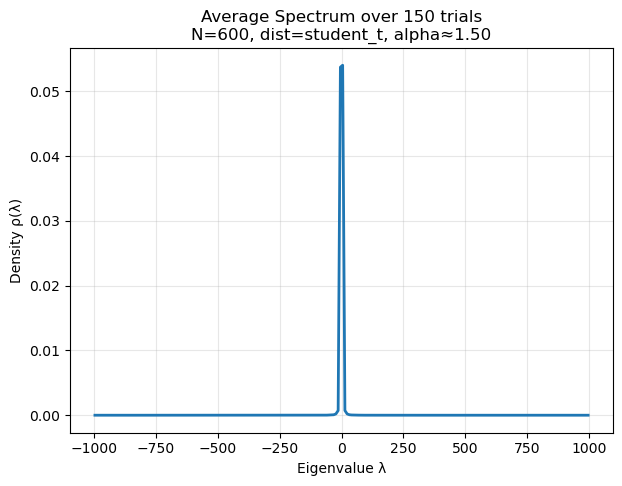

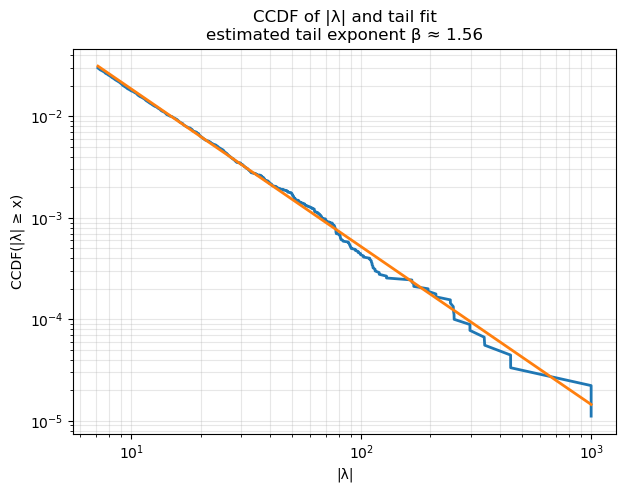

1.5551131885728053

In [2]:
# Complete, self-contained script for simulating spectra of large symmetric matrices
# with different element distributions (Gaussian, Student-t, symmetric Pareto),
# averaging spectra over many trials, and estimating tail exponents.
#
# You can change CONFIG at the top and re-run.

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
N = 600                # matrix size
n_trials = 150         # number of trials to average
dist = "student_t"     # options: "gaussian", "student_t", "pareto"
gauss_sigma = 1.0      # std for gaussian entries before scaling
student_df = 1.5       # degrees of freedom for Student-t (tail ~ x^{-(df+1)})
pareto_alpha = 1.5     # Pareto tail exponent (P(|X|>x) ~ x^{-alpha})
hist_bins = 220        # bins for spectrum histogram
tail_quantile = 0.97   # start quantile for tail-fit on |lambda| CCDF (e.g., top 3%)

np.random.seed(0)

# -------------------------
# helpers: sampling
# -------------------------
def sample_entries(shape, dist, gauss_sigma, student_df, pareto_alpha):
    if dist == "gaussian":
        M = np.random.normal(loc=0.0, scale=gauss_sigma, size=shape)
        scale = (shape[0])**0.5  # N^{1/2}
        return M / scale, 2.0  # return matrix and alpha_equiv for info
    elif dist == "student_t":
        # numpy's standard_t gives Student-t with df
        # Tail exponent alpha = df (since P(|X|>x) ~ x^{-df})
        M = np.random.standard_t(df=student_df, size=shape)
        scale = (shape[0])**(1.0 / student_df)  # N^{1/alpha}
        return M / scale, student_df
    elif dist == "pareto":
        # symmetric Pareto: draw Y~Pareto(alpha) with support y>=1, then random sign
        Y = 1.0 + np.random.pareto(pareto_alpha, size=shape)  # tail ~ x^{-(alpha+1)} for pdf, CDF tail exponent alpha
        signs = np.random.choice([-1.0, 1.0], size=shape)
        M = signs * Y
        scale = (shape[0])**(1.0 / pareto_alpha)  # N^{1/alpha}
        return M / scale, pareto_alpha
    else:
        raise ValueError("Unknown dist")

# -------------------------
# run trials and collect eigenvalues
# -------------------------
all_eigs = []

for _ in range(n_trials):
    M, alpha_equiv = sample_entries((N, N), dist, gauss_sigma, student_df, pareto_alpha)
    # symmetrize
    M = 0.5 * (M + M.T)
    # compute eigenvalues
    w = np.linalg.eigvalsh(M)
    all_eigs.append(w)

all_eigs = np.concatenate(all_eigs, axis=0)

# -------------------------
# average spectrum histogram
# -------------------------
hist, bin_edges = np.histogram(all_eigs, bins=hist_bins, density=True)
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure(figsize=(7,5))
plt.plot(centers, hist, linewidth=2)
plt.title(f"Average Spectrum over {n_trials} trials\nN={N}, dist={dist}, alpha≈{alpha_equiv:.2f}")
plt.xlabel("Eigenvalue λ")
plt.ylabel("Density ρ(λ)")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------
# tail CCDF (|λ|) and power-law fit
# -------------------------
abs_vals = np.abs(all_eigs)
sorted_abs = np.sort(abs_vals)
q_idx = int(tail_quantile * sorted_abs.size)
tail_x = sorted_abs[q_idx:]
# empirical CCDF
# for each value v, CCDF(v) ~ fraction of |λ| >= v
# Compute on unique grid to avoid duplicates issues
unique_tail = np.unique(tail_x)
ccdf = 1.0 - np.searchsorted(sorted_abs, unique_tail, side="left") / sorted_abs.size

# linear fit on log-log
logx = np.log(unique_tail + 1e-12)
logy = np.log(ccdf + 1e-12)
# use only the last half of tail points for stability
half = max(20, len(logx)//2)
coef = np.polyfit(logx[-half:], logy[-half:], 1)
slope, intercept = coef[0], coef[1]
beta_est = -slope  # CCDF ~ x^{-beta_est}

plt.figure(figsize=(7,5))
plt.loglog(unique_tail, ccdf, linewidth=2)
# fitted line
fit_y = np.exp(intercept) * (unique_tail ** slope)
plt.loglog(unique_tail, fit_y, linewidth=2)
plt.title(f"CCDF of |λ| and tail fit\nestimated tail exponent β ≈ {beta_est:.2f}")
plt.xlabel("|λ|")
plt.ylabel("CCDF(|λ| ≥ x)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

beta_est
